In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import re

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting
from setting_for_sdm.constants import CONSTANTS

from lib.code_complexity.cyclomatic_complexity import calculate_cyclomatic_complexity
from lib.utils.file_io import read_complexity_jsonl

import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from matplotlib import pyplot as plt

import matplotlib as mpl
import lib.visualization.plot_generator as PlotGen
import lib.visualization.font_setting as font_setting
mpl.rcParams['font.family'] = font_setting.init_font()

import statsmodels.formula.api as smf
from scipy import stats





Helvetica /home/mghan/.fonts/Helvetica/Helvetica Oblique.ttf
Registered font name: Helvetica


In [2]:
def draw_cyclomatic_complexity_scatter_plot(idx_num, viz_df, x_col, y_col, option_dict, output_dir, opt):
    sharey = False ## 또는 sharey=False
    sharex = True ## 또는 sharex=False

    fig, axs = mpl.pyplot.subplots(figsize = (12, 6), constrained_layout=True)
    title = y_col.replace("_", " ").title()

    plotgen = PlotGen.PlotGen()
    x= list(viz_df[x_col])
    y= list(viz_df[y_col])
    print(option_dict["selected_tags"])
    plotgen.draw_regression_with_chow(axs
                                , f'{title} for {option_dict["selected_tags"]}({opt})' 
                                , x
                                , y
                                , None
                                , None
                                , None
                                , False
                                )

    fig.supxlabel("Weeks relative to ChatGPT release", fontsize=22) 
    fig.supylabel(f'Weekly average {title}', fontsize=22)
    filename = f"{idx_num}_scatter_plot_{option_dict['selected_tags']}_{y_col}_{option_dict['year_range']}_{opt}.png"
    plt.savefig(
    os.path.join(output_dir, filename),
    dpi=300,
    bbox_inches='tight'
    )
    plt.close(fig)

In [3]:
run_id_start = 20000

for idx, lang in enumerate(list({lang: set_ for lang, set_ in CONSTANTS.LANG_INFO.items() if set_[1] is not None}.keys())):
    print(f'[visualizing....] start visualizing {lang} language')
    output_dir = create_dir('./fig/')
    src_dir = f'{path_list["data_root_dir"]}/result/code_complexity/cyclomatic_complexity/run_id_{run_id_start+idx}'
    option_dict = load_json(f"{src_dir}/data/option.json")
    std_date = Date_Setting[option_dict['year_range']]['std_date']

    origin_df = load_df(option_dict['data_dir'], ['id', 'creationdate', 'title','tags', 'body'])

    df = read_complexity_jsonl(option_dict)
    # df = calculate_cyclomatic_complexity(df, "sum")
    df['cyclomatic_complexity'] = np.log(df['cyclomatic_complexity']+1)

    viz_df = pd.merge(df, origin_df, on = 'id')[['id', 'creationdate', 'cyclomatic_complexity']]
    viz_df['rel_week'] = np.floor((pd.to_datetime(viz_df['creationdate'], format='mixed')- std_date).dt.days/7)
    viz_df = (viz_df.groupby('rel_week', as_index=False)['cyclomatic_complexity'].mean())


    draw_cyclomatic_complexity_scatter_plot(run_id_start + idx, viz_df, 'rel_week', 'cyclomatic_complexity', option_dict, output_dir, 'all')


[visualizing....] start visualizing python language


 25%|██▍       | 16/65 [00:04<00:14,  3.30it/s]


KeyboardInterrupt: 

In [4]:
run_id_start = 20000

tot_viz_df = pd.DataFrame()
for idx, lang in enumerate(list({lang: set_ for lang, set_ in CONSTANTS.LANG_INFO.items() if set_[1] is not None}.keys())):
    print(f'[visualizing....] start visualizing {lang} language')
    output_dir = create_dir('./fig/')
    src_dir = f'{path_list["data_root_dir"]}/result/code_complexity/cyclomatic_complexity/run_id_{run_id_start+idx}'
    option_dict = load_json(f"{src_dir}/data/option.json")
    std_date = Date_Setting[option_dict['year_range']]['std_date']

    origin_df = load_df(option_dict['data_dir'], ['id', 'creationdate', 'title','tags', 'body'])
    df = read_complexity_jsonl(option_dict)
    viz_df = pd.merge(df, origin_df, on = 'id')[['id', 'creationdate', 'cyclomatic_complexity', 'nloc']]
    viz_df['language'] = lang
    tot_viz_df = pd.concat([tot_viz_df, viz_df], ignore_index=True)




[visualizing....] start visualizing python language


100%|██████████| 65/65 [00:21<00:00,  2.97it/s]


[visualizing....] start visualizing javascript language


100%|██████████| 65/65 [00:14<00:00,  4.54it/s]


[visualizing....] start visualizing java language


...

100%|██████████| 65/65 [00:00<00:00, 612.10it/s]


[visualizing....] start visualizing fortran language


100%|██████████| 65/65 [00:00<00:00, 536.56it/s]


[visualizing....] start visualizing solidity language


100%|██████████| 65/65 [00:00<00:00, 316.29it/s]


In [ ]:
tot_viz_df.head()

In [ ]:
df

In [ ]:
tot_viz_df

초기 데이터: 3,365개 행, 19개 언어

=== 종속변수 분포 비교 ===
log_cc_mean: mean=0.945, std=0.114, range=[0.703, 1.506]
cc_mean_raw: mean=1.897, std=0.502, range=[1.024, 5.135]

1단계: 데이터 진단

빈별 표본 분포:
       n_obs  n_lang  total_func
count   66.0    66.0        66.0
mean    51.0    14.2     29137.6
std     12.3     2.5     19558.3
min     13.0     6.0       629.0
25%     48.0    13.0     10606.5
50%     56.0    15.0     26200.5
75%     59.0    16.0     47149.5
max     64.0    18.0     61321.0

빈×언어 매트릭스: 316/1254 셀 비어 있음 (25.2%)

3단계: 통합 Event Study 회귀
log_cc_mean ~ C(event_bin, Treatment(reference=-1)) + C(language)

4단계: Pre-trends 검정

[선형 추세 검정]
  Slope: +0.00013/bin (p=0.2172)
  R²:    0.0602
  ✅ Pre-trends 추세 없음 (DiD 가정 충족)

[Pre-bins 평균 = 0 검정]
  평균 효과: -0.00614 (= -0.61%)
  t=-7.787, p=0.0000

[개별 pre-bin 검정, Bonferroni 보정]
  유의한 pre-bin: 2/26

5단계: 처치 후 효과 요약

[처치 후 빈 효과] (log 단위 → % 변환)
  평균 효과:      +0.02479 (= +2.51%)
  중앙값 효과:    +0.02083 (= +2.10%)
  유의한 빈 수:   19/38
  양수 빈 수:     34/38

[처

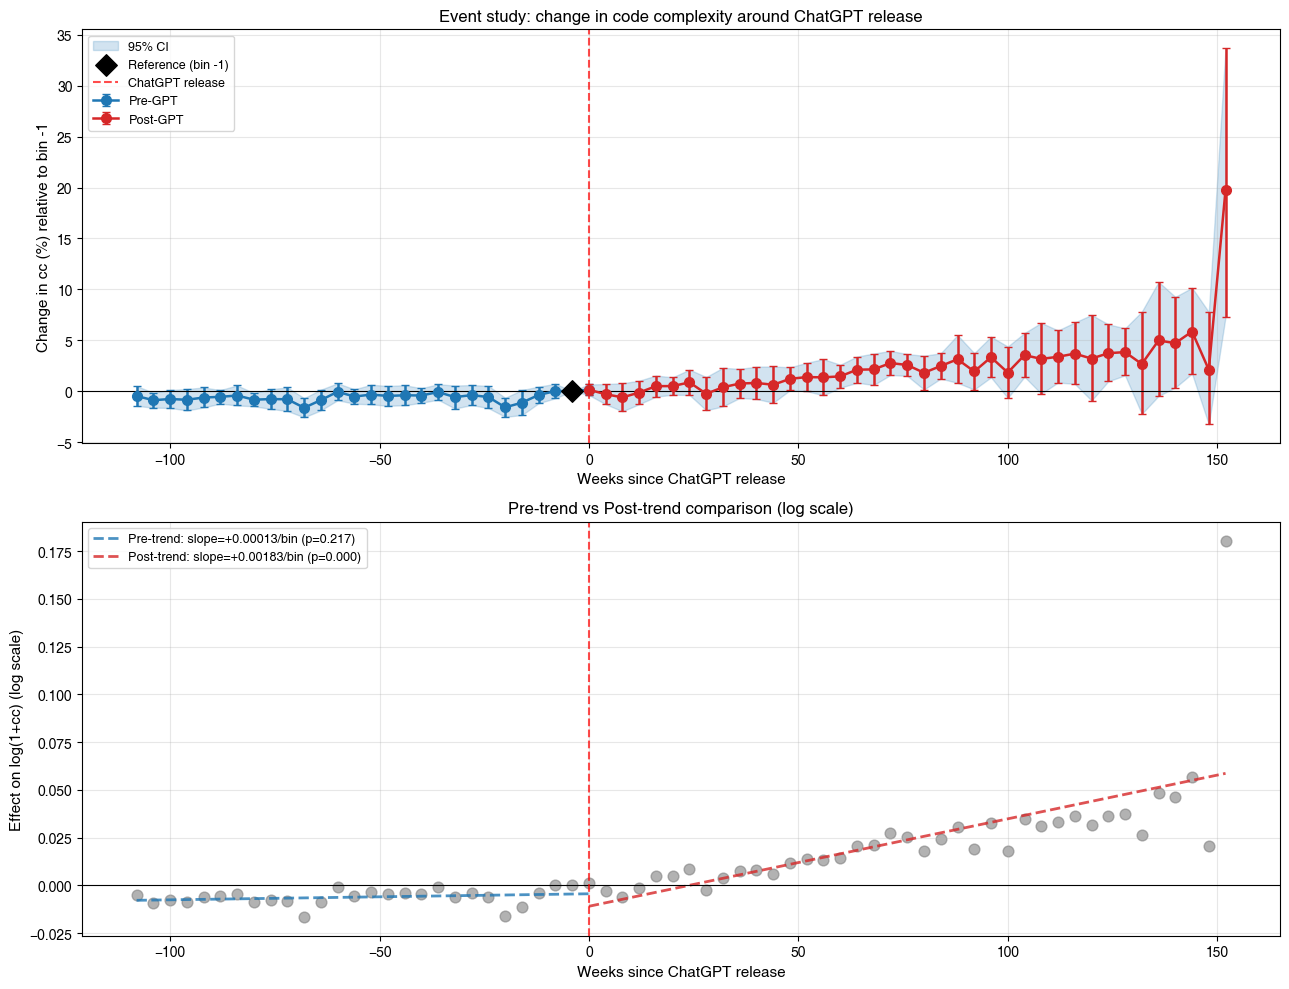


6단계: 언어별 Event Study


/home/mghan/sopjt/git/so_difficulty_measure/venv_so_difficulty_measure/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1885: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


[SKIP] lua: NaN SE


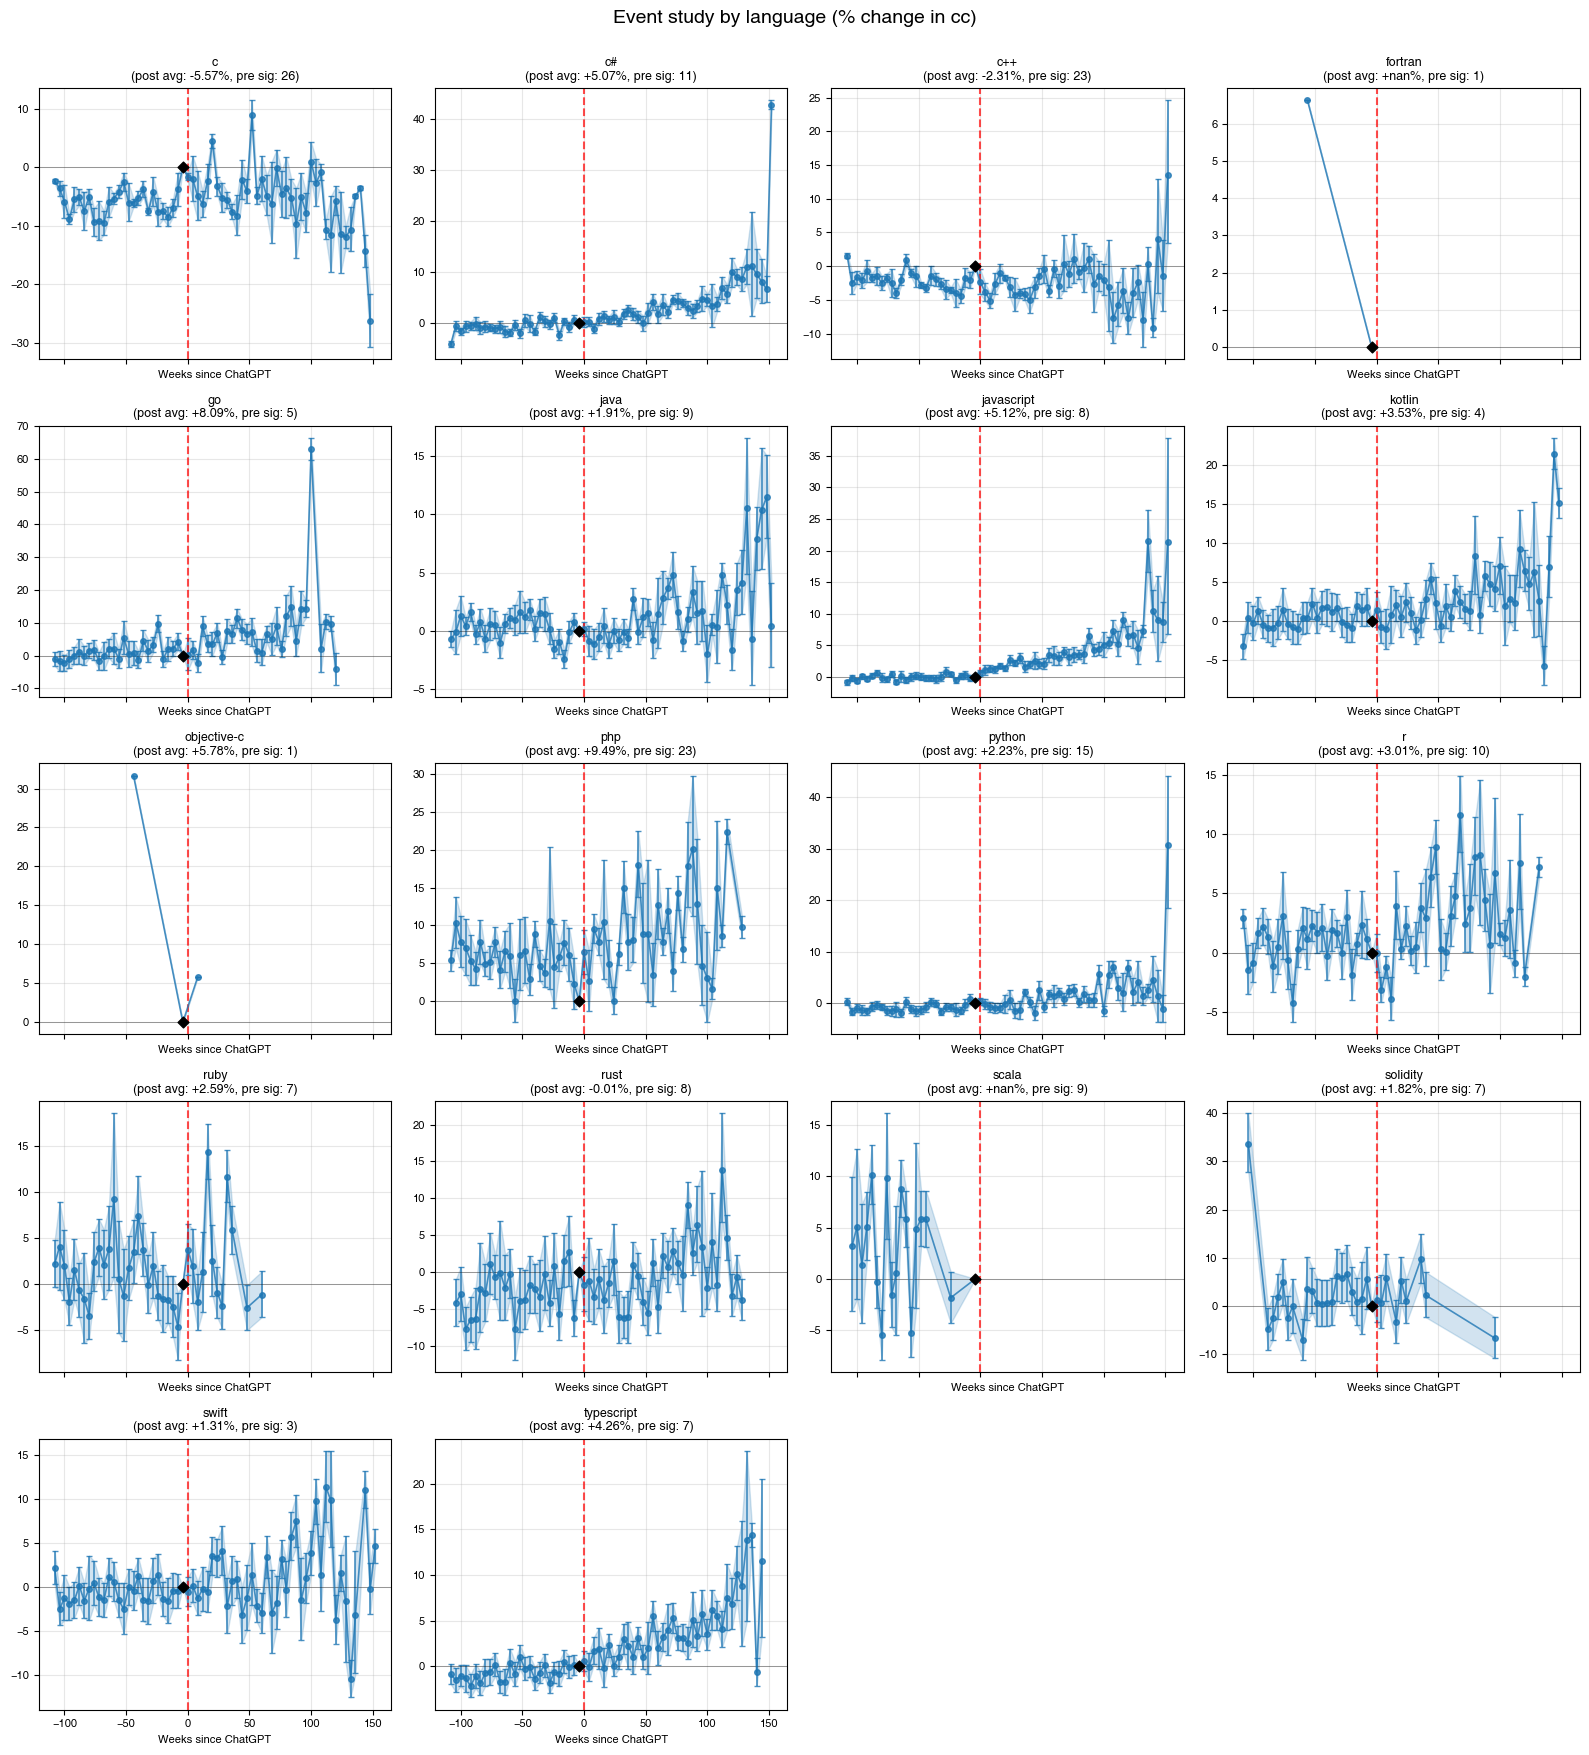


분석 완료
통합 결과: pool_df (coef는 log 단위, coef_pct는 % 변환)
언어별 결과: ev_lang_df


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import linregress, ttest_1samp
from statsmodels.stats.multitest import multipletests

# ═══════════════════════════════════════════
# 0. 설정
# ═══════════════════════════════════════════
CHATGPT_DATE = pd.Timestamp('2022-11-30')
TARGET       = 'log_cc_mean'         # ⭐ 변수명 정직하게
BIN_SIZE     = 4
MIN_BIN      = -28
MAX_BIN      = +39
REF_BIN      = -1

MIN_LANGS_PER_BIN = 10
MIN_FUNC_PER_CELL = 50

# ═══════════════════════════════════════════
# 1. 데이터 준비
# ═══════════════════════════════════════════
df = tot_viz_df.copy()
df['creationdate'] = pd.to_datetime(df['creationdate'], format='mixed')
df = df[df['cyclomatic_complexity'] > 0].dropna(subset=['nloc']).copy()

# ⭐ 함수 단위에서 log 변환 (raw cc는 이상치 영향 큼)
df['log_cc'] = np.log1p(df['cyclomatic_complexity'])

df['week'] = df['creationdate'].dt.to_period('W').dt.start_time

valid = df['language'].value_counts()[lambda s: s >= 1000].index
df = df[df['language'].isin(valid)].copy()

# 주별 × 언어별 집계
weekly_var = df.groupby(['language', 'week']).agg(
    log_cc_mean = ('log_cc', 'mean'),                       # ⭐ log → mean
    log_cc_std  = ('log_cc', 'std'),
    cc_mean_raw = ('cyclomatic_complexity', 'mean'),        # 비교용 (raw)
    cc_std_raw  = ('cyclomatic_complexity', 'std'),
    n_func      = ('cyclomatic_complexity', 'count'),
).reset_index()

weekly_var = weekly_var[weekly_var['n_func'] >= 30].copy()
weekly_var['weeks_since'] = (weekly_var['week'] - CHATGPT_DATE).dt.days / 7

# Event time 빈
weekly_var['event_bin'] = (weekly_var['weeks_since'] // BIN_SIZE).astype(int)
weekly_var = weekly_var[
    (weekly_var['event_bin'] >= MIN_BIN) &
    (weekly_var['event_bin'] <= MAX_BIN)
].copy()

print(f"초기 데이터: {len(weekly_var):,}개 행, {weekly_var['language'].nunique()}개 언어")

# ⭐ log_cc_mean과 raw cc_mean 분포 비교 (확인용)
print(f"\n=== 종속변수 분포 비교 ===")
print(f"log_cc_mean: mean={weekly_var['log_cc_mean'].mean():.3f}, "
      f"std={weekly_var['log_cc_mean'].std():.3f}, "
      f"range=[{weekly_var['log_cc_mean'].min():.3f}, {weekly_var['log_cc_mean'].max():.3f}]")
print(f"cc_mean_raw: mean={weekly_var['cc_mean_raw'].mean():.3f}, "
      f"std={weekly_var['cc_mean_raw'].std():.3f}, "
      f"range=[{weekly_var['cc_mean_raw'].min():.3f}, {weekly_var['cc_mean_raw'].max():.3f}]")

# ═══════════════════════════════════════════
# 2. 진단
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("1단계: 데이터 진단")
print("="*60)

clean_data = weekly_var.dropna(subset=[TARGET])

bin_stats = clean_data.groupby('event_bin').agg(
    n_obs=(TARGET, 'count'),
    n_lang=('language', 'nunique'),
    total_func=('n_func', 'sum'),
).reset_index()
print(f"\n빈별 표본 분포:")
print(bin_stats.describe()[['n_obs', 'n_lang', 'total_func']].round(1))

pivot = clean_data.pivot_table(
    index='event_bin', columns='language',
    values=TARGET, aggfunc='count', fill_value=0,
)
n_empty = (pivot == 0).sum().sum()
n_total = pivot.size
print(f"\n빈×언어 매트릭스: {n_empty}/{n_total} 셀 비어 있음 ({n_empty/n_total*100:.1f}%)")

# ═══════════════════════════════════════════
# 3. 데이터 정제 (현재 비활성)
# ═══════════════════════════════════════════
weekly_clean = weekly_var.copy()

# ═══════════════════════════════════════════
# 4. 통합 Event Study 회귀
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("3단계: 통합 Event Study 회귀")
print("="*60)

formula_pool = (f'{TARGET} ~ C(event_bin, Treatment(reference={REF_BIN}))'
                f' + C(language)')

m_pool = smf.wls(formula_pool, data=weekly_clean,
                 weights=weekly_clean['n_func']).fit(
    cov_type='cluster', cov_kwds={'groups': weekly_clean['language']},
)
print(formula_pool)

pool_results = []
for term in m_pool.params.index:
    if 'C(event_bin' not in term:
        continue
    bin_val = int(term.split('T.')[1].split(']')[0])
    pool_results.append({
        'event_bin': bin_val,
        'weeks':     bin_val * BIN_SIZE,
        'coef':      m_pool.params[term],
        'se':        m_pool.bse[term],
        'p_value':   m_pool.pvalues[term],
        'ci_low':    m_pool.params[term] - 1.96 * m_pool.bse[term],
        'ci_high':   m_pool.params[term] + 1.96 * m_pool.bse[term],
    })
pool_results.append({
    'event_bin': REF_BIN, 'weeks': REF_BIN * BIN_SIZE,
    'coef': 0, 'se': 0, 'p_value': 1, 'ci_low': 0, 'ci_high': 0,
})
pool_df = pd.DataFrame(pool_results).sort_values('event_bin').reset_index(drop=True)

# ⭐ % 단위 변환 추가 (log 회귀 → % 해석)
def beta_to_pct(beta):
    """log 회귀 계수 → % 변화"""
    return (np.exp(beta) - 1) * 100

pool_df['coef_pct']    = beta_to_pct(pool_df['coef'])
pool_df['ci_low_pct']  = beta_to_pct(pool_df['coef'] - 1.96 * pool_df['se'])
pool_df['ci_high_pct'] = beta_to_pct(pool_df['coef'] + 1.96 * pool_df['se'])

# ═══════════════════════════════════════════
# 5. Pre-trends 검정
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("4단계: Pre-trends 검정")
print("="*60)

pre_data = pool_df[pool_df['event_bin'] < 0].copy()

if len(pre_data) > 3:
    res = linregress(pre_data['event_bin'], pre_data['coef'])
    print(f"\n[선형 추세 검정]")
    print(f"  Slope: {res.slope:+.5f}/bin (p={res.pvalue:.4f})")
    print(f"  R²:    {res.rvalue**2:.4f}")
    if res.pvalue > 0.05:
        print("  ✅ Pre-trends 추세 없음 (DiD 가정 충족)")
    else:
        print("  ⚠️ Pre-trends에 추세 있음")

if len(pre_data) > 0:
    t, p = ttest_1samp(pre_data['coef'], 0)
    print(f"\n[Pre-bins 평균 = 0 검정]")
    print(f"  평균 효과: {pre_data['coef'].mean():+.5f} (= {beta_to_pct(pre_data['coef'].mean()):+.2f}%)")
    print(f"  t={t:.3f}, p={p:.4f}")

if len(pre_data) > 1:
    pre_with_p = pre_data[pre_data['p_value'] < 1].copy()
    if len(pre_with_p) > 0:
        _, pre_p_adj, _, _ = multipletests(pre_with_p['p_value'].values, method='bonferroni')
        n_sig = (pre_p_adj < 0.05).sum()
        print(f"\n[개별 pre-bin 검정, Bonferroni 보정]")
        print(f"  유의한 pre-bin: {n_sig}/{len(pre_with_p)}")

# ═══════════════════════════════════════════
# 6. 처치 후 효과 요약 (% 단위 추가)
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("5단계: 처치 후 효과 요약")
print("="*60)

post_data = pool_df[pool_df['event_bin'] > 0]
print(f"\n[처치 후 빈 효과] (log 단위 → % 변환)")
print(f"  평균 효과:      {post_data['coef'].mean():+.5f} "
      f"(= {beta_to_pct(post_data['coef'].mean()):+.2f}%)")
print(f"  중앙값 효과:    {post_data['coef'].median():+.5f} "
      f"(= {beta_to_pct(post_data['coef'].median()):+.2f}%)")
print(f"  유의한 빈 수:   {(post_data['p_value'] < 0.05).sum()}/{len(post_data)}")
print(f"  양수 빈 수:     {(post_data['coef'] > 0).sum()}/{len(post_data)}")

if len(post_data) > 3:
    res_post = linregress(post_data['event_bin'], post_data['coef'])
    print(f"\n[처치 후 추세]")
    print(f"  Slope: {res_post.slope:+.5f}/bin (p={res_post.pvalue:.4f})")
    print(f"  → 처치 후 효과가 시간 지나며 {'증가' if res_post.slope > 0 else '감소'}")

# 누적 효과 (마지막 빈)
final_β = post_data['coef'].iloc[-1]
final_pct = beta_to_pct(final_β)
final_week = post_data['weeks'].iloc[-1]
print(f"\n[누적 효과 (최종 시점)]")
print(f"  {final_week}주 시점: β={final_β:+.4f} → {final_pct:+.2f}%")

# ═══════════════════════════════════════════
# 7. 시각화 — % 단위로 표시
# ═══════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# (1) 메인 Event Study Plot
ax = axes[0]

# 신뢰구간 (% 단위)
ax.fill_between(pool_df['weeks'], pool_df['ci_low_pct'], pool_df['ci_high_pct'],
                alpha=0.2, color='C0', label='95% CI')

pre  = pool_df[pool_df['event_bin'] <= 0]
post = pool_df[pool_df['event_bin'] >= 0]

# Errorbar도 % 단위
ax.errorbar(pre['weeks'], pre['coef_pct'], 
            yerr=[pre['coef_pct']-pre['ci_low_pct'], pre['ci_high_pct']-pre['coef_pct']],
            fmt='o-', markersize=7, capsize=3, lw=1.8, color='C0', label='Pre-GPT')
ax.errorbar(post['weeks'], post['coef_pct'],
            yerr=[post['coef_pct']-post['ci_low_pct'], post['ci_high_pct']-post['coef_pct']],
            fmt='o-', markersize=7, capsize=3, lw=1.8, color='C3', label='Post-GPT')

ax.scatter([REF_BIN * BIN_SIZE], [0], color='black', s=120, 
           zorder=5, marker='D', label=f'Reference (bin {REF_BIN})')

ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='red', ls='--', alpha=0.7, label='ChatGPT release')

ax.set_xlabel('Weeks since ChatGPT release', fontsize=11)
ax.set_ylabel(f'Change in cc (%) relative to bin {REF_BIN}', fontsize=11)   # ⭐ % 라벨
ax.set_title(f'Event study: change in code complexity around ChatGPT release', fontsize=12)
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

# (2) Pre/Post 추세선 시각화 (log 단위 그대로)
ax = axes[1]

ax.scatter(pool_df['weeks'], pool_df['coef'], 
           s=60, alpha=0.6, color='gray')

if len(pre_data) > 3:
    x_pre = np.linspace(pre_data['weeks'].min(), 0, 50)
    y_pre = res.intercept + res.slope * (x_pre / BIN_SIZE)
    ax.plot(x_pre, y_pre, 'C0--', lw=2, alpha=0.8,
            label=f'Pre-trend: slope={res.slope:+.5f}/bin (p={res.pvalue:.3f})')

if len(post_data) > 3:
    x_post = np.linspace(0, post_data['weeks'].max(), 50)
    y_post = res_post.intercept + res_post.slope * (x_post / BIN_SIZE)
    ax.plot(x_post, y_post, 'C3--', lw=2, alpha=0.8,
            label=f'Post-trend: slope={res_post.slope:+.5f}/bin (p={res_post.pvalue:.3f})')

ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='red', ls='--', alpha=0.7)

ax.set_xlabel('Weeks since ChatGPT release', fontsize=11)
ax.set_ylabel(f'Effect on log(1+cc) (log scale)', fontsize=11)
ax.set_title('Pre-trend vs Post-trend comparison (log scale)', fontsize=12)
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('event_study_pooled.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════
# 8. 언어별 Event Study (그리드)
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("6단계: 언어별 Event Study")
print("="*60)

event_results_lang = []
for lang in weekly_clean['language'].unique():
    sub = weekly_clean[weekly_clean['language'] == lang]
    # if len(sub) < 20:
    #     continue
    
    formula = f'{TARGET} ~ C(event_bin, Treatment(reference={REF_BIN}))'
    
    try:
        m = smf.wls(formula, data=sub, weights=sub['n_func']).fit(
            cov_type='HAC', cov_kwds={'maxlags': 3},
        )
    except Exception:
        continue
    
    if m.bse.isna().any():
        print(f"[SKIP] {lang}: NaN SE")
        continue
    
    for term in m.params.index:
        if 'C(event_bin' not in term:
            continue
        bin_val = int(term.split('T.')[1].split(']')[0])
        event_results_lang.append({
            'language':  lang,
            'event_bin': bin_val,
            'weeks':     bin_val * BIN_SIZE,
            'coef':      m.params[term],
            'coef_pct':  beta_to_pct(m.params[term]),    # ⭐ % 추가
            'se':        m.bse[term],
            'p_value':   m.pvalues[term],
            'ci_low':    m.params[term] - 1.96 * m.bse[term],
            'ci_high':   m.params[term] + 1.96 * m.bse[term],
        })
    event_results_lang.append({
        'language': lang, 'event_bin': REF_BIN, 'weeks': REF_BIN * BIN_SIZE,
        'coef': 0, 'coef_pct': 0,
        'se': 0, 'p_value': 1, 'ci_low': 0, 'ci_high': 0,
    })

ev_lang_df = pd.DataFrame(event_results_lang)
ev_lang_df['ci_low_pct']  = beta_to_pct(ev_lang_df['ci_low'])
ev_lang_df['ci_high_pct'] = beta_to_pct(ev_lang_df['ci_high'])

# 언어별 그리드 (% 단위로 표시)
languages = sorted(ev_lang_df['language'].unique())
n_lang = len(languages)
n_cols = 4
n_rows = (n_lang + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows),
                         sharex=True, sharey=False)
axes_flat = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for ax, lang in zip(axes_flat, languages):
    sub = ev_lang_df[ev_lang_df['language'] == lang].sort_values('event_bin')
    
    ax.fill_between(sub['weeks'], sub['ci_low_pct'], sub['ci_high_pct'],
                    alpha=0.2, color='C0')
    ax.errorbar(sub['weeks'], sub['coef_pct'],
                yerr=[sub['coef_pct']-sub['ci_low_pct'], sub['ci_high_pct']-sub['coef_pct']],
                fmt='o-', markersize=4, capsize=2, lw=1.2, color='C0', alpha=0.8)
    
    ax.axhline(0, color='black', lw=0.5, alpha=0.5)
    ax.axvline(0, color='red', ls='--', alpha=0.7)
    ax.scatter([REF_BIN * BIN_SIZE], [0], color='black', s=30, zorder=5, marker='D')
    
    post_mean_pct = sub[sub['event_bin'] > 0]['coef_pct'].mean()
    pre_sig = (sub[sub['event_bin'] < 0]['p_value'] < 0.05).sum()
    
    ax.set_title(f'{lang}\n(post avg: {post_mean_pct:+.2f}%, pre sig: {pre_sig})',
                 fontsize=9)
    ax.set_xlabel('Weeks since ChatGPT', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3)

for ax in axes_flat[len(languages):]:
    ax.axis('off')

plt.suptitle(f'Event study by language (% change in cc)', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('event_study_by_language.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("분석 완료")
print("="*60)
print(f"통합 결과: pool_df (coef는 log 단위, coef_pct는 % 변환)")
print(f"언어별 결과: ev_lang_df")

In [16]:
ev_lang_df['language'].unique()

array(['c', 'c#', 'c++', 'fortran', 'go', 'java', 'javascript', 'kotlin',
       'objective-c', 'php', 'python', 'r', 'ruby', 'rust', 'scala',
       'solidity', 'swift', 'typescript'], dtype=object)

시각화용 데이터 범위: -108 ~ 152 weeks
점 개수: 66


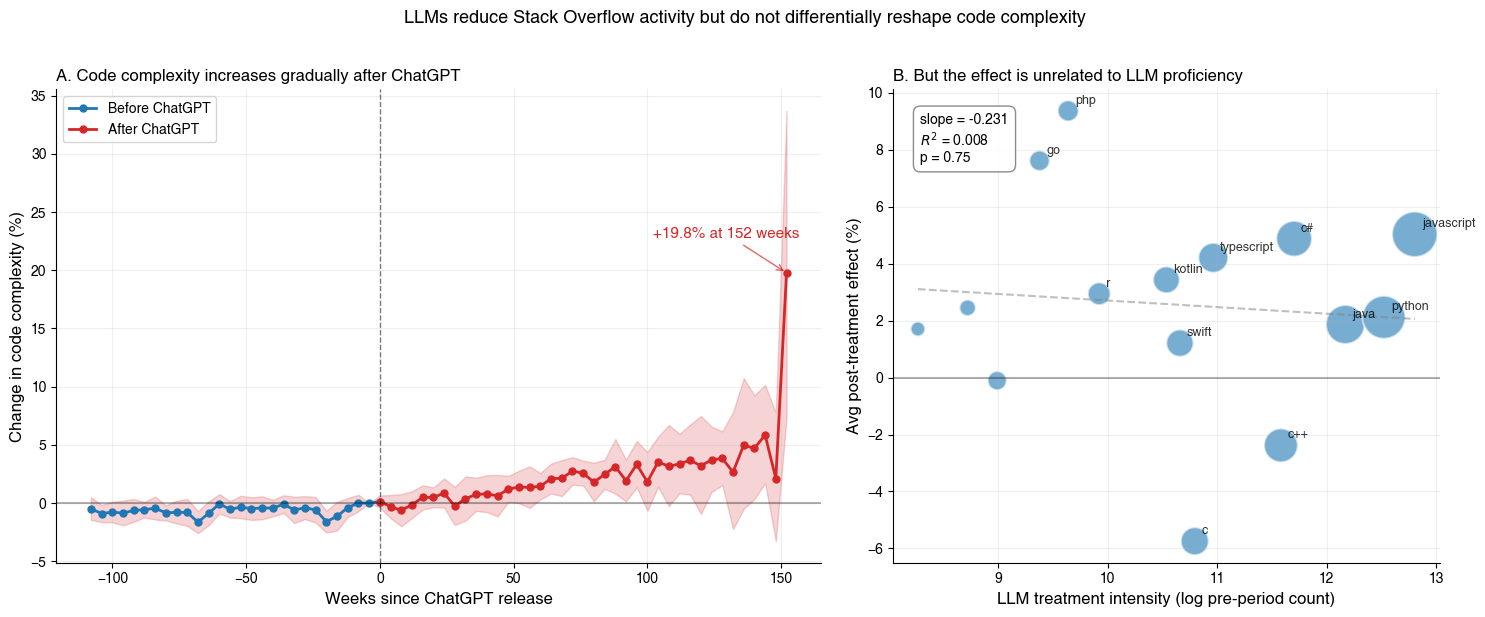

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ───────────────────────────────────────────
# % 변환 함수 (log 회귀용)
# ───────────────────────────────────────────
def beta_to_pct(beta):
    """log 회귀 계수 → % 변화"""
    return (np.exp(beta) - 1) * 100

# ───────────────────────────────────────────
# 사전 준비
# ───────────────────────────────────────────
BIN_SIZE = 4

# pool_df는 이미 coef, se 등을 가지고 있음 (log 단위)
agg = pool_df.copy()
agg['weeks'] = agg['event_bin'] * BIN_SIZE

# ⭐ % 변환 (log 회귀이므로 exp 변환)
agg['coef_pct']    = beta_to_pct(agg['coef'])
agg['ci_low_pct']  = beta_to_pct(agg['coef'] - 1.96 * agg['se'])
agg['ci_high_pct'] = beta_to_pct(agg['coef'] + 1.96 * agg['se'])

print(f"시각화용 데이터 범위: {agg['weeks'].min()} ~ {agg['weeks'].max()} weeks")
print(f"점 개수: {len(agg)}")

# ───────────────────────────────────────────
# Panel B 데이터 (LLM 친화도 vs 효과)
# ───────────────────────────────────────────
lang_post_effects = (ev_lang_df[ev_lang_df['event_bin'] > 0]
                     .groupby('language')
                     .agg(mean_coef=('coef', 'mean'),
                          n_bins=('coef', 'count'))
                     .reset_index())

# LLM 친화도 (사전 인기도 log)
pre_counts = df[df['creationdate'] < CHATGPT_DATE]['language'].value_counts()
intensity_log = np.log(pre_counts + 1).to_dict()

lang_post_effects['intensity'] = lang_post_effects['language'].map(intensity_log)
lang_post_effects = lang_post_effects.dropna(subset=['intensity']).copy()

# ⭐ % 변환 (log 회귀의 평균 계수 → % 변화)
lang_post_effects['effect_pct'] = beta_to_pct(lang_post_effects['mean_coef'])

# 표본 크기
lang_total = df['language'].value_counts().to_dict()
lang_post_effects['n_total'] = lang_post_effects['language'].map(lang_total)

# 회귀 (% 단위)
res = linregress(lang_post_effects['intensity'], lang_post_effects['effect_pct'])

# ═══════════════════════════════════════════
# 메인 그림
# ═══════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(15, 6),
                         gridspec_kw={'width_ratios': [1.4, 1]})

# ───────────────────────────────────────────
# Panel A: Event study
# ───────────────────────────────────────────
ax = axes[0]

# 신뢰밴드
ax.fill_between(agg['weeks'], agg['ci_low_pct'], agg['ci_high_pct'],
                alpha=0.2, color='#d62728')

# 처치 전후 색깔
pre  = agg[agg['weeks'] <= 0].sort_values('weeks')
post = agg[agg['weeks'] >= 0].sort_values('weeks')

ax.plot(pre['weeks'],  pre['coef_pct'], 'o-', color='#1f77b4',
        lw=2, markersize=5, label='Before ChatGPT')
ax.plot(post['weeks'], post['coef_pct'], 'o-', color='#d62728',
        lw=2, markersize=5, label='After ChatGPT')

ax.axvline(0, color='black', ls='--', alpha=0.5, lw=1)
ax.axhline(0, color='black', alpha=0.3)

# 누적 효과 표시
final_pct  = post['coef_pct'].iloc[-1]
final_week = post['weeks'].iloc[-1]

ax.annotate(f'+{final_pct:.1f}% at {final_week:.0f} weeks',
            xy=(final_week, final_pct),
            xytext=(final_week - 50, final_pct + 3),
            fontsize=11, fontweight='bold', color='#d62728',
            arrowprops=dict(arrowstyle='->', color='#d62728', alpha=0.7))

ax.set_xlabel('Weeks since ChatGPT release', fontsize=12)
ax.set_ylabel('Change in code complexity (%)', fontsize=12)
ax.set_title('A. Code complexity increases gradually after ChatGPT',
             fontsize=12, fontweight='bold', loc='left')
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ───────────────────────────────────────────
# Panel B: LLM 친화도 vs 효과
# ───────────────────────────────────────────
ax = axes[1]

sizes = np.sqrt(lang_post_effects['n_total']) * 1.5

ax.scatter(lang_post_effects['intensity'], lang_post_effects['effect_pct'],
           s=sizes, alpha=0.6, color='#1f77b4',
           edgecolor='white', lw=1.5)

x_line = np.linspace(lang_post_effects['intensity'].min(),
                     lang_post_effects['intensity'].max(), 100)
ax.plot(x_line, res.intercept + res.slope * x_line,
        '--', color='gray', alpha=0.5, lw=1.5)

ax.axhline(0, color='black', alpha=0.3)

# 언어 라벨
for _, row in lang_post_effects.iterrows():
    if row['n_total'] > 20000 or abs(row['effect_pct']) > 5:
        ax.annotate(row['language'],
                    (row['intensity'], row['effect_pct']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, alpha=0.8)

# 통계량
stats_text = (f"slope = {res.slope:+.3f}\n"
              f"$R^2$ = {res.rvalue**2:.3f}\n"
              f"p = {res.pvalue:.2f}")
ax.text(0.05, 0.95, stats_text,
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5',
                  facecolor='white', alpha=0.9, edgecolor='gray'))

ax.set_xlabel('LLM treatment intensity (log pre-period count)', fontsize=12)
ax.set_ylabel('Avg post-treatment effect (%)', fontsize=12)
ax.set_title('B. But the effect is unrelated to LLM proficiency',
             fontsize=12, fontweight='bold', loc='left')
ax.grid(alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('LLMs reduce Stack Overflow activity but do not differentially reshape code complexity',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('main_figure_time_vs_llm.png', dpi=300, bbox_inches='tight')
plt.show()

언어별 효과 요약 — 리뷰어 응답용 테이블

[언어별 효과 — 평균 효과 큰 순]
  language  n_func    pre_p  post_slope       post_p  avg_effect_pct  final_effect_pct
       php   22694 0.115315    0.001558 1.447459e-01        9.356355          9.783286
        go   20020 0.009511    0.003237 1.055720e-01        7.605489         -4.086384
javascript  504473 0.161688    0.002887 1.567711e-08        5.025020         21.289816
        c#  192153 0.019293    0.003667 2.841864e-06        4.870634         42.784242
typescript   93127 0.010239    0.002439 3.716624e-07        4.200091         11.513151
    kotlin   60187 0.019017    0.002205 5.168237e-04        3.427358         15.069544
         r   31513 0.682217    0.001346 6.243422e-02        2.938114          7.256850
      ruby    8372 0.220768   -0.002108 6.300191e-01        2.444761         -1.151057
    python  406621 0.191427    0.002057 1.892333e-03        2.113741         30.750402
      java  273043 0.432701    0.001655 2.057632e-04        1.860985          0.4175

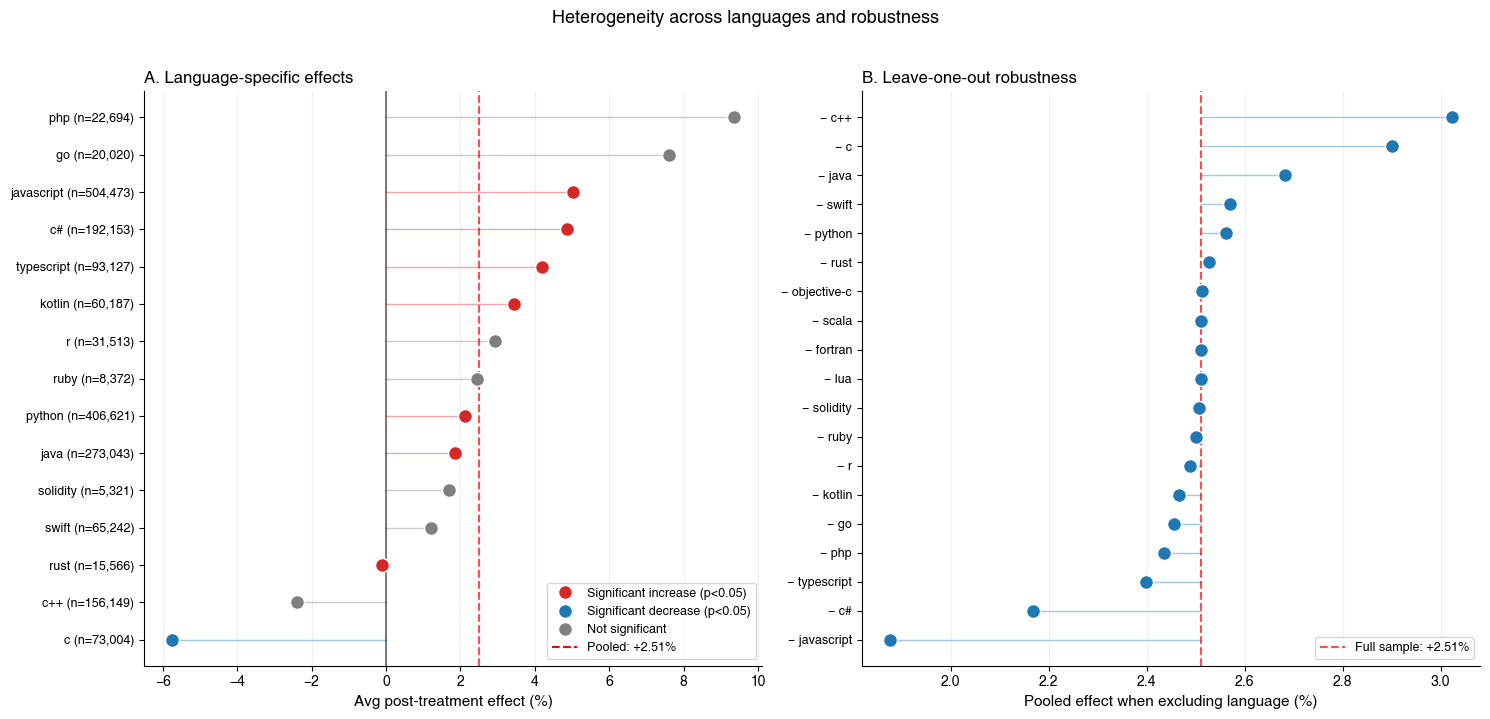

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import linregress

# % 변환 함수
def beta_to_pct(beta):
    return (np.exp(beta) - 1) * 100

# ═══════════════════════════════════════════
# 1. 언어별 효과 요약 테이블
# ═══════════════════════════════════════════
print("="*70)
print("언어별 효과 요약 — 리뷰어 응답용 테이블")
print("="*70)

lang_summary = []
for lang in ev_lang_df['language'].unique():
    sub = ev_lang_df[ev_lang_df['language'] == lang].dropna(subset=['coef'])
    
    pre  = sub[sub['event_bin'] < 0]
    post = sub[sub['event_bin'] > 0]
    
    if len(pre) < 3 or len(post) < 3:
        continue
    
    # Pre-trend
    res_pre = linregress(pre['event_bin'], pre['coef'])
    
    # Post-trend
    res_post = linregress(post['event_bin'], post['coef'])
    
    # 평균 효과
    post_avg = post['coef'].mean()
    
    # 마지막 시점 누적 효과
    final_β = post['coef'].iloc[-1]
    
    lang_summary.append({
        'language':         lang,
        'n_func':           df[df['language'] == lang].shape[0],
        'pre_slope':        res_pre.slope,
        'pre_p':            res_pre.pvalue,
        'post_slope':       res_post.slope,
        'post_p':           res_post.pvalue,
        'avg_effect':       post_avg,
        'avg_effect_pct':   beta_to_pct(post_avg),
        'final_effect_pct': beta_to_pct(final_β),
    })

ldf = pd.DataFrame(lang_summary).sort_values('avg_effect', ascending=False)

print("\n[언어별 효과 — 평균 효과 큰 순]")
print(ldf[['language', 'n_func', 'pre_p', 'post_slope', 'post_p',
            'avg_effect_pct', 'final_effect_pct']].to_string(index=False))

# ═══════════════════════════════════════════
# 2. Leave-One-Out 분석
# ═══════════════════════════════════════════
print("\n" + "="*70)
print("Leave-One-Out: 각 언어 빼고 통합 결과 재추정")
print("="*70)

loo_results = []
formula_pool = (f'{TARGET} ~ C(event_bin, Treatment(reference={REF_BIN}))'
                f' + C(language)')

for excl_lang in weekly_clean['language'].unique():
    sub = weekly_clean[weekly_clean['language'] != excl_lang]
    
    try:
        m = smf.wls(formula_pool, data=sub,
                    weights=sub['n_func']).fit(
            cov_type='cluster', cov_kwds={'groups': sub['language']},
        )
    except Exception:
        continue
    
    # 처치 후 평균
    post_terms = [t for t in m.params.index 
                  if 'C(event_bin' in t and 
                  int(t.split('T.')[1].split(']')[0]) > 0]
    post_betas = [m.params[t] for t in post_terms]
    
    loo_results.append({
        'excluded':       excl_lang,
        'avg_effect':     np.mean(post_betas),
        'avg_effect_pct': beta_to_pct(np.mean(post_betas)),
    })

loo_df = pd.DataFrame(loo_results).sort_values('avg_effect_pct')

# 전체 표본 결과
full_post_terms = [t for t in m_pool.params.index 
                    if 'C(event_bin' in t and 
                    int(t.split('T.')[1].split(']')[0]) > 0]
full_avg = np.mean([m_pool.params[t] for t in full_post_terms])
full_pct = beta_to_pct(full_avg)

print(f"\n전체 표본: {full_pct:+.2f}%")
print(f"\n각 언어 제외 시 결과:")
print(loo_df[['excluded', 'avg_effect_pct']].to_string(index=False))

# 변동 폭
print(f"\n변동 폭: {loo_df['avg_effect_pct'].min():.2f}% ~ {loo_df['avg_effect_pct'].max():.2f}%")
print(f"전체 대비: {(loo_df['avg_effect_pct'].max() - loo_df['avg_effect_pct'].min()):.2f}%p")

# ═══════════════════════════════════════════
# 3. 시각화 — Forest plot (언어별)
# ═══════════════════════════════════════════
print("\n" + "="*70)
print("그림 생성")
print("="*70)

# 카테고리 분류
def categorize(row):
    if row['post_p'] >= 0.05:
        return 'gray'
    elif row['post_slope'] > 0:
        return 'red'
    else:
        return 'blue'

ldf['color'] = ldf.apply(categorize, axis=1)
color_hex = {'red': '#d62728', 'blue': '#1f77b4', 'gray': '#7f7f7f'}

# Forest plot: 언어별 평균 효과 + Leave-one-out
fig, axes = plt.subplots(1, 2, figsize=(15, max(7, len(ldf) * 0.4)),
                         gridspec_kw={'width_ratios': [1, 1]})

# (좌) 언어별 처치 후 평균 효과
ax = axes[0]
sorted_eff = ldf.sort_values('avg_effect_pct').reset_index(drop=True)

for i, row in sorted_eff.iterrows():
    color = color_hex[row['color']]
    ax.scatter(row['avg_effect_pct'], i, s=100, color=color,
               edgecolor='white', lw=1, zorder=3)
    # 0 라인까지 막대
    ax.plot([0, row['avg_effect_pct']], [i, i], color=color, lw=1, alpha=0.4)

ax.axvline(0, color='black', ls='-', alpha=0.5)
ax.axvline(full_pct, color='red', ls='--', alpha=0.7, lw=1.5,
           label=f'Pooled: {full_pct:+.2f}%')

ax.set_yticks(np.arange(len(sorted_eff)))
ax.set_yticklabels([f"{r['language']} (n={r['n_func']:,})" 
                    for _, r in sorted_eff.iterrows()], fontsize=9)
ax.set_xlabel('Avg post-treatment effect (%)', fontsize=11)
ax.set_title('A. Language-specific effects', fontsize=12, fontweight='bold', loc='left')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, axis='x', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# (우) Leave-one-out
ax = axes[1]
loo_sorted = loo_df.sort_values('avg_effect_pct').reset_index(drop=True)

for i, row in loo_sorted.iterrows():
    ax.scatter(row['avg_effect_pct'], i, s=100, color='#1f77b4',
               edgecolor='white', lw=1, zorder=3)
    ax.plot([full_pct, row['avg_effect_pct']], [i, i], 
            color='#1f77b4', lw=1, alpha=0.4)

ax.axvline(full_pct, color='red', ls='--', alpha=0.7, lw=1.5,
           label=f'Full sample: {full_pct:+.2f}%')

ax.set_yticks(np.arange(len(loo_sorted)))
ax.set_yticklabels([f"− {r['excluded']}" for _, r in loo_sorted.iterrows()],
                   fontsize=9)
ax.set_xlabel('Pooled effect when excluding language (%)', fontsize=11)
ax.set_title('B. Leave-one-out robustness', fontsize=12, fontweight='bold', loc='left')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, axis='x', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 범례 (Panel A 색상)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728',
           markersize=10, label='Significant increase (p<0.05)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4',
           markersize=10, label='Significant decrease (p<0.05)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#7f7f7f',
           markersize=10, label='Not significant'),
]
axes[0].legend(handles=legend_elements + 
               [Line2D([0], [0], color='red', ls='--', label=f'Pooled: {full_pct:+.2f}%')],
               loc='lower right', fontsize=9)

plt.suptitle('Heterogeneity across languages and robustness',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('language_heterogeneity.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# ═══════════════════════════════════════════
# 0. 설정
# ═══════════════════════════════════════════
CHATGPT_DATE = pd.Timestamp('2022-11-30')   # 진짜 GPT
PLACEBO_DATE = pd.Timestamp('2021-11-30')   # 가짜 GPT (1년 전)

TARGET   = 'log_cc_mean'
BIN_SIZE = 4
MIN_BIN  = -28
MAX_BIN  = +13      # 진짜 GPT 직전까지만 (오염 방지)
REF_BIN  = -1

def beta_to_pct(beta):
    return (np.exp(beta) - 1) * 100

# ═══════════════════════════════════════════
# 1. Placebo용 데이터 준비
# ═══════════════════════════════════════════
df_placebo = tot_viz_df.copy()
df_placebo['creationdate'] = pd.to_datetime(df_placebo['creationdate'], format='mixed')
df_placebo = df_placebo[df_placebo['cyclomatic_complexity'] > 0].dropna(subset=['nloc']).copy()

# ⭐ 핵심: 진짜 GPT 이전 데이터만 사용
df_placebo = df_placebo[df_placebo['creationdate'] < CHATGPT_DATE].copy()

# log 변환
df_placebo['log_cc'] = np.log1p(df_placebo['cyclomatic_complexity'])
df_placebo['week'] = df_placebo['creationdate'].dt.to_period('W').dt.start_time

# 표본 충분한 언어만
valid = df_placebo['language'].value_counts()[lambda s: s >= 1000].index
df_placebo = df_placebo[df_placebo['language'].isin(valid)].copy()

print(f"Placebo 데이터: {len(df_placebo):,}개 함수")
print(f"기간: {df_placebo['creationdate'].min().date()} ~ {df_placebo['creationdate'].max().date()}")

# ═══════════════════════════════════════════
# 2. 주별 × 언어별 집계
# ═══════════════════════════════════════════
weekly_placebo = df_placebo.groupby(['language', 'week']).agg(
    log_cc_mean = ('log_cc', 'mean'),
    n_func      = ('cyclomatic_complexity', 'count'),
).reset_index()

weekly_placebo = weekly_placebo[weekly_placebo['n_func'] >= 30].copy()

# ⭐ Placebo 시점 기준 weeks_since
weekly_placebo['weeks_since'] = (weekly_placebo['week'] - PLACEBO_DATE).dt.days / 7

# Event time 빈
weekly_placebo['event_bin'] = (weekly_placebo['weeks_since'] // BIN_SIZE).astype(int)
weekly_placebo = weekly_placebo[
    (weekly_placebo['event_bin'] >= MIN_BIN) &
    (weekly_placebo['event_bin'] <= MAX_BIN)
].copy()

print(f"\n분석 데이터: {len(weekly_placebo):,}개 행, {weekly_placebo['language'].nunique()}개 언어")
print(f"빈 범위: {weekly_placebo['event_bin'].min()} ~ {weekly_placebo['event_bin'].max()}")

# ═══════════════════════════════════════════
# 3. Placebo Event Study 회귀
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("Placebo Event Study 회귀")
print("="*60)

formula = f'{TARGET} ~ C(event_bin, Treatment(reference={REF_BIN})) + C(language)'

m_placebo = smf.wls(formula, data=weekly_placebo,
                    weights=weekly_placebo['n_func']).fit(
    cov_type='cluster', cov_kwds={'groups': weekly_placebo['language']},
)

# ═══════════════════════════════════════════
# 4. 결과 → placebo_df 만들기
# ═══════════════════════════════════════════
placebo_results = []
for term in m_placebo.params.index:
    if 'C(event_bin' not in term:
        continue
    bin_val = int(term.split('T.')[1].split(']')[0])
    placebo_results.append({
        'event_bin': bin_val,
        'weeks':     bin_val * BIN_SIZE,
        'coef':      m_placebo.params[term],
        'se':        m_placebo.bse[term],
        'p_value':   m_placebo.pvalues[term],
        'ci_low':    m_placebo.params[term] - 1.96 * m_placebo.bse[term],
        'ci_high':   m_placebo.params[term] + 1.96 * m_placebo.bse[term],
    })

# 기준 빈 추가 (β_{-1} = 0)
placebo_results.append({
    'event_bin': REF_BIN, 'weeks': REF_BIN * BIN_SIZE,
    'coef': 0, 'se': 0, 'p_value': 1, 'ci_low': 0, 'ci_high': 0,
})

# DataFrame 생성
placebo_df = pd.DataFrame(placebo_results).sort_values('event_bin').reset_index(drop=True)

# ⭐ % 단위 변환 (pool_df와 동일한 구조)
placebo_df['coef_pct']    = beta_to_pct(placebo_df['coef'])
placebo_df['ci_low_pct']  = beta_to_pct(placebo_df['coef'] - 1.96 * placebo_df['se'])
placebo_df['ci_high_pct'] = beta_to_pct(placebo_df['coef'] + 1.96 * placebo_df['se'])

print(f"\nplacebo_df 생성 완료: {len(placebo_df)}개 빈")
print(placebo_df.head())

# ═══════════════════════════════════════════
# 5. 핵심 통계 출력 (옵션 1 시각화에 필요)
# ═══════════════════════════════════════════
from scipy.stats import linregress

# Real (이전 분석의 pool_df 사용)
real_pre  = pool_df[pool_df['event_bin'] < 0]
real_post = pool_df[pool_df['event_bin'] > 0]
real_pre_slope  = linregress(real_pre['event_bin'], real_pre['coef'])
real_post_slope = linregress(real_post['event_bin'], real_post['coef'])

# Placebo
placebo_pre  = placebo_df[placebo_df['event_bin'] < 0]
placebo_post = placebo_df[placebo_df['event_bin'] > 0]
placebo_pre_slope  = linregress(placebo_pre['event_bin'], placebo_pre['coef'])
placebo_post_slope = linregress(placebo_post['event_bin'], placebo_post['coef'])

print("\n" + "="*60)
print("Real vs Placebo 비교")
print("="*60)
print(f"\n{'':25s}  {'Real':>15s}  {'Placebo':>15s}")
print(f"{'-'*60}")
print(f"{'Pre-slope':25s}  "
      f"{real_pre_slope.slope:+15.5f}  "
      f"{placebo_pre_slope.slope:+15.5f}")
print(f"{'Pre-slope p':25s}  "
      f"{real_pre_slope.pvalue:>15.4f}  "
      f"{placebo_pre_slope.pvalue:>15.4f}")
print(f"{'Post-slope':25s}  "
      f"{real_post_slope.slope:+15.5f}  "
      f"{placebo_post_slope.slope:+15.5f}")
print(f"{'Post-slope p':25s}  "
      f"{real_post_slope.pvalue:>15.4f}  "
      f"{placebo_post_slope.pvalue:>15.4f}")
print(f"{'Post avg (%)':25s}  "
      f"{beta_to_pct(real_post['coef'].mean()):>14.2f}%  "
      f"{beta_to_pct(placebo_post['coef'].mean()):>14.2f}%")

Placebo 데이터: 1,315,836개 함수
기간: 2020-12-02 ~ 2022-11-29

분석 데이터: 1,564개 행, 17개 언어
빈 범위: -14 ~ 12

Placebo Event Study 회귀

placebo_df 생성 완료: 27개 빈
   event_bin  weeks      coef        se   p_value    ci_low   ci_high  \
0        -14    -56  0.000251  0.006899  0.970975 -0.013270  0.013772   
1        -13    -52 -0.003769  0.002215  0.088813 -0.008111  0.000572   
2        -12    -48 -0.002412  0.002396  0.313991 -0.007108  0.002284   
3        -11    -44 -0.003146  0.002647  0.234543 -0.008334  0.002041   
4        -10    -40 -0.000988  0.002051  0.630124 -0.005008  0.003033   

   coef_pct  ci_low_pct  ci_high_pct  
0  0.025104   -1.318274     1.386770  
1 -0.376212   -0.807776     0.057230  
2 -0.240941   -0.708294     0.228611  
3 -0.314129   -0.829914     0.204338  
4 -0.098733   -0.499587     0.303737  

Real vs Placebo 비교

                                      Real          Placebo
------------------------------------------------------------
Pre-slope                         +0.000

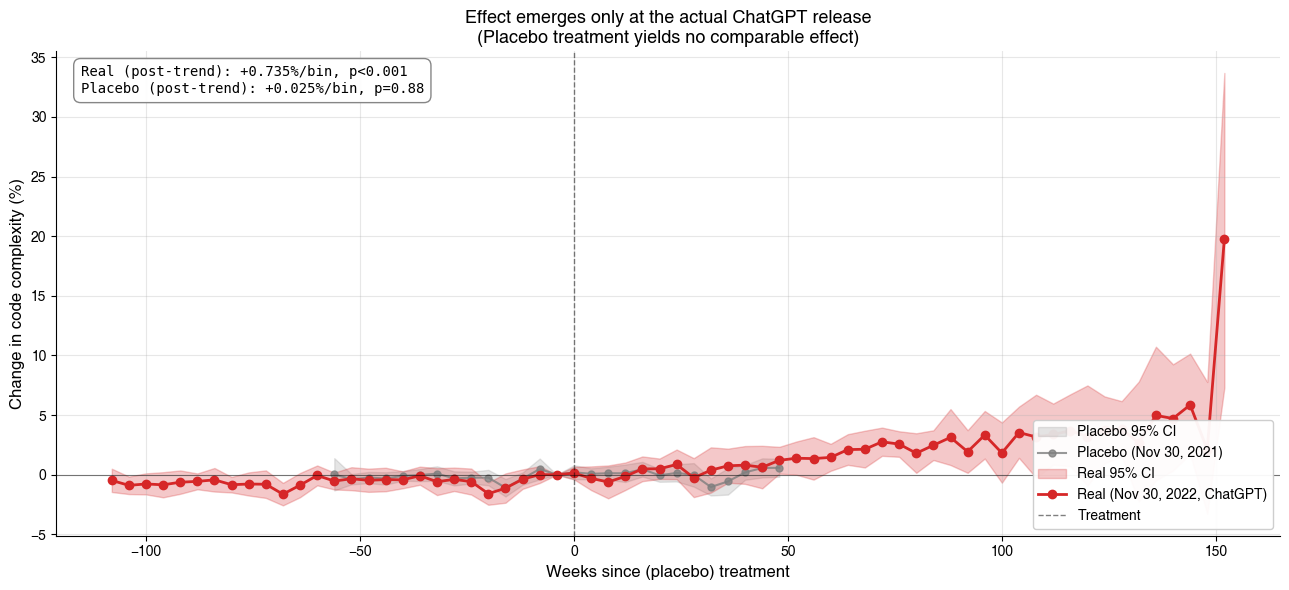

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 6))

# Placebo (회색, 뒤로)
ax.fill_between(placebo_df['weeks'], placebo_df['ci_low_pct'], placebo_df['ci_high_pct'],
                alpha=0.2, color='#7f7f7f', label='Placebo 95% CI')

ax.plot(placebo_df['weeks'], placebo_df['coef_pct'], 
        'o-', markersize=5, lw=1.5, color='#7f7f7f', alpha=0.8,
        label='Placebo (Nov 30, 2021)')

# Real (빨강, 앞으로)
ax.fill_between(pool_df['weeks'], pool_df['ci_low_pct'], pool_df['ci_high_pct'],
                alpha=0.25, color='#d62728', label='Real 95% CI')

ax.plot(pool_df['weeks'], pool_df['coef_pct'],
        'o-', markersize=6, lw=2, color='#d62728',
        label='Real (Nov 30, 2022, ChatGPT)')

# 0 라인과 처치 시점
ax.axhline(0, color='black', alpha=0.5, lw=0.8)
ax.axvline(0, color='black', ls='--', alpha=0.5, lw=1, label='Treatment')

# 라벨
ax.set_xlabel('Weeks since (placebo) treatment', fontsize=12)
ax.set_ylabel('Change in code complexity (%)', fontsize=12)
ax.set_title('Effect emerges only at the actual ChatGPT release\n'
             '(Placebo treatment yields no comparable effect)',
             fontsize=13, fontweight='bold')

# 통계 박스
stats_text = (
    f"Real (post-trend): {beta_to_pct(real_post_slope.slope*BIN_SIZE):+.3f}%/bin, p<0.001\n"
    f"Placebo (post-trend): {beta_to_pct(placebo_post_slope.slope*BIN_SIZE):+.3f}%/bin, p={placebo_post_slope.pvalue:.2f}"
)
ax.text(0.02, 0.97, stats_text,
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5',
                  facecolor='white', alpha=0.95, edgecolor='gray'))

ax.legend(loc='lower right', fontsize=10, framealpha=0.95)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('placebo_overlay.png', dpi=300, bbox_inches='tight')
plt.show()